In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import xarray as xr
import numpy as np
import natsort
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys

function_path = "../functions/"
sys.path.append(function_path)
# from KCC_function import *
from Plot_function import *
from analysis_function import *
from obs_function import *

In [4]:
path = "../input_file/"
#### Grid monthly analysis data
# name = 'HadCRUT.5.0.2.0.analysis.anomalies.ensemble_mean.nc'
# f = xr.open_dataset(path + name)
# tas_had = f['tas_mean'].rename({'latitude': 'lat','longitude': 'lon'})

#### Non-infilled data
name = "HadCRUT.5.0.2.0.non-infilled.anomalies.ensemble_mean.nc"
f = xr.open_dataset(path + name)
tas_had_nan = f["tas_mean"].rename({"latitude": "lat", "longitude": "lon"})
tas_had_reshaped_nan = tas_had_nan.groupby("time.year").apply(
    lambda x: x.groupby("time.month").mean()
)
tas_had_yr_mon_nan = tas_had_reshaped_nan.transpose("year", "month", "lat", "lon")

### Quality control for grid

#### On each grid, we require at least one month per quarter, three-quarters per year

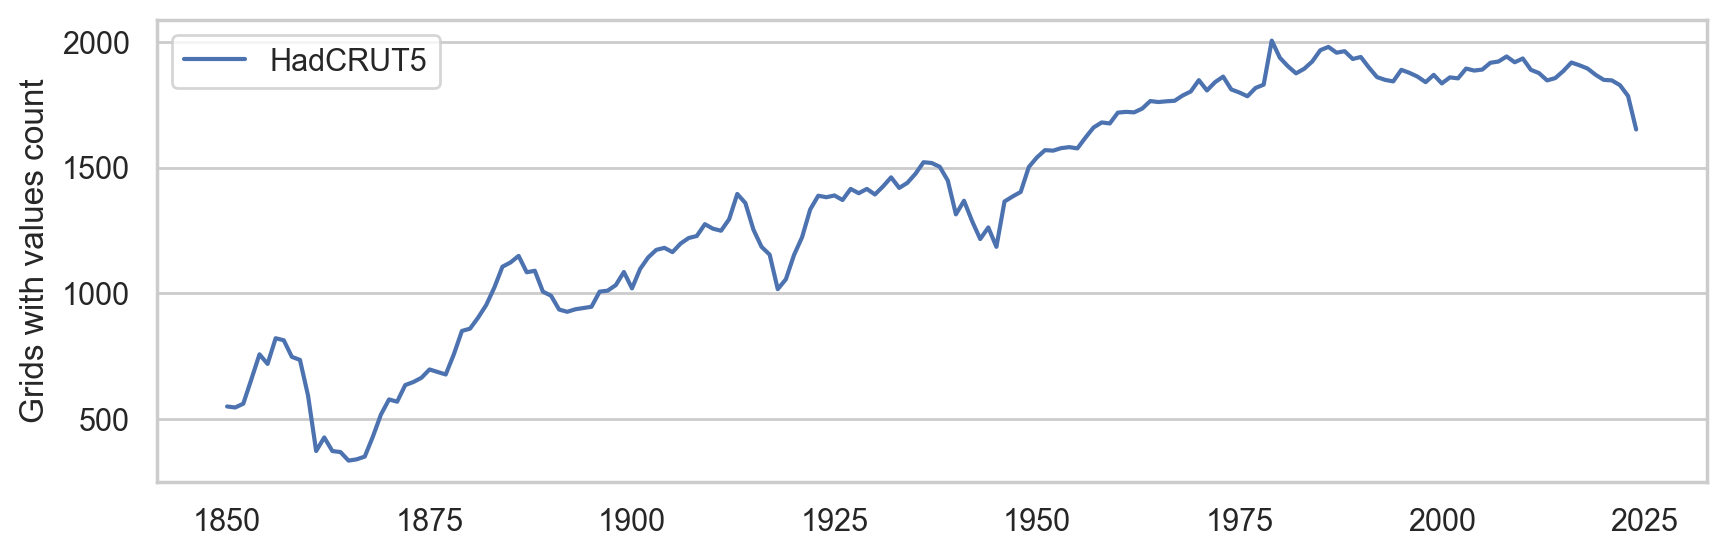

In [5]:
tas_had_yr_75per = filter_years_with_valid_quarters(
    tas_had_yr_mon_nan, min_valid_quarters=3
)

notnan_counts_grid_had, notnan_percent_had = notnan_count(tas_had_yr_75per)

fig = plt.figure(figsize=(10, 3), dpi=200)
sns.set_theme(style="whitegrid", rc={"axes.grid.axis": "y"})
plt.plot(notnan_counts_grid_had["year"], notnan_counts_grid_had, label="HadCRUT5")
plt.legend()
# plt.ylim(0,1)
plt.ylabel("Grids with values count")
plt.show()

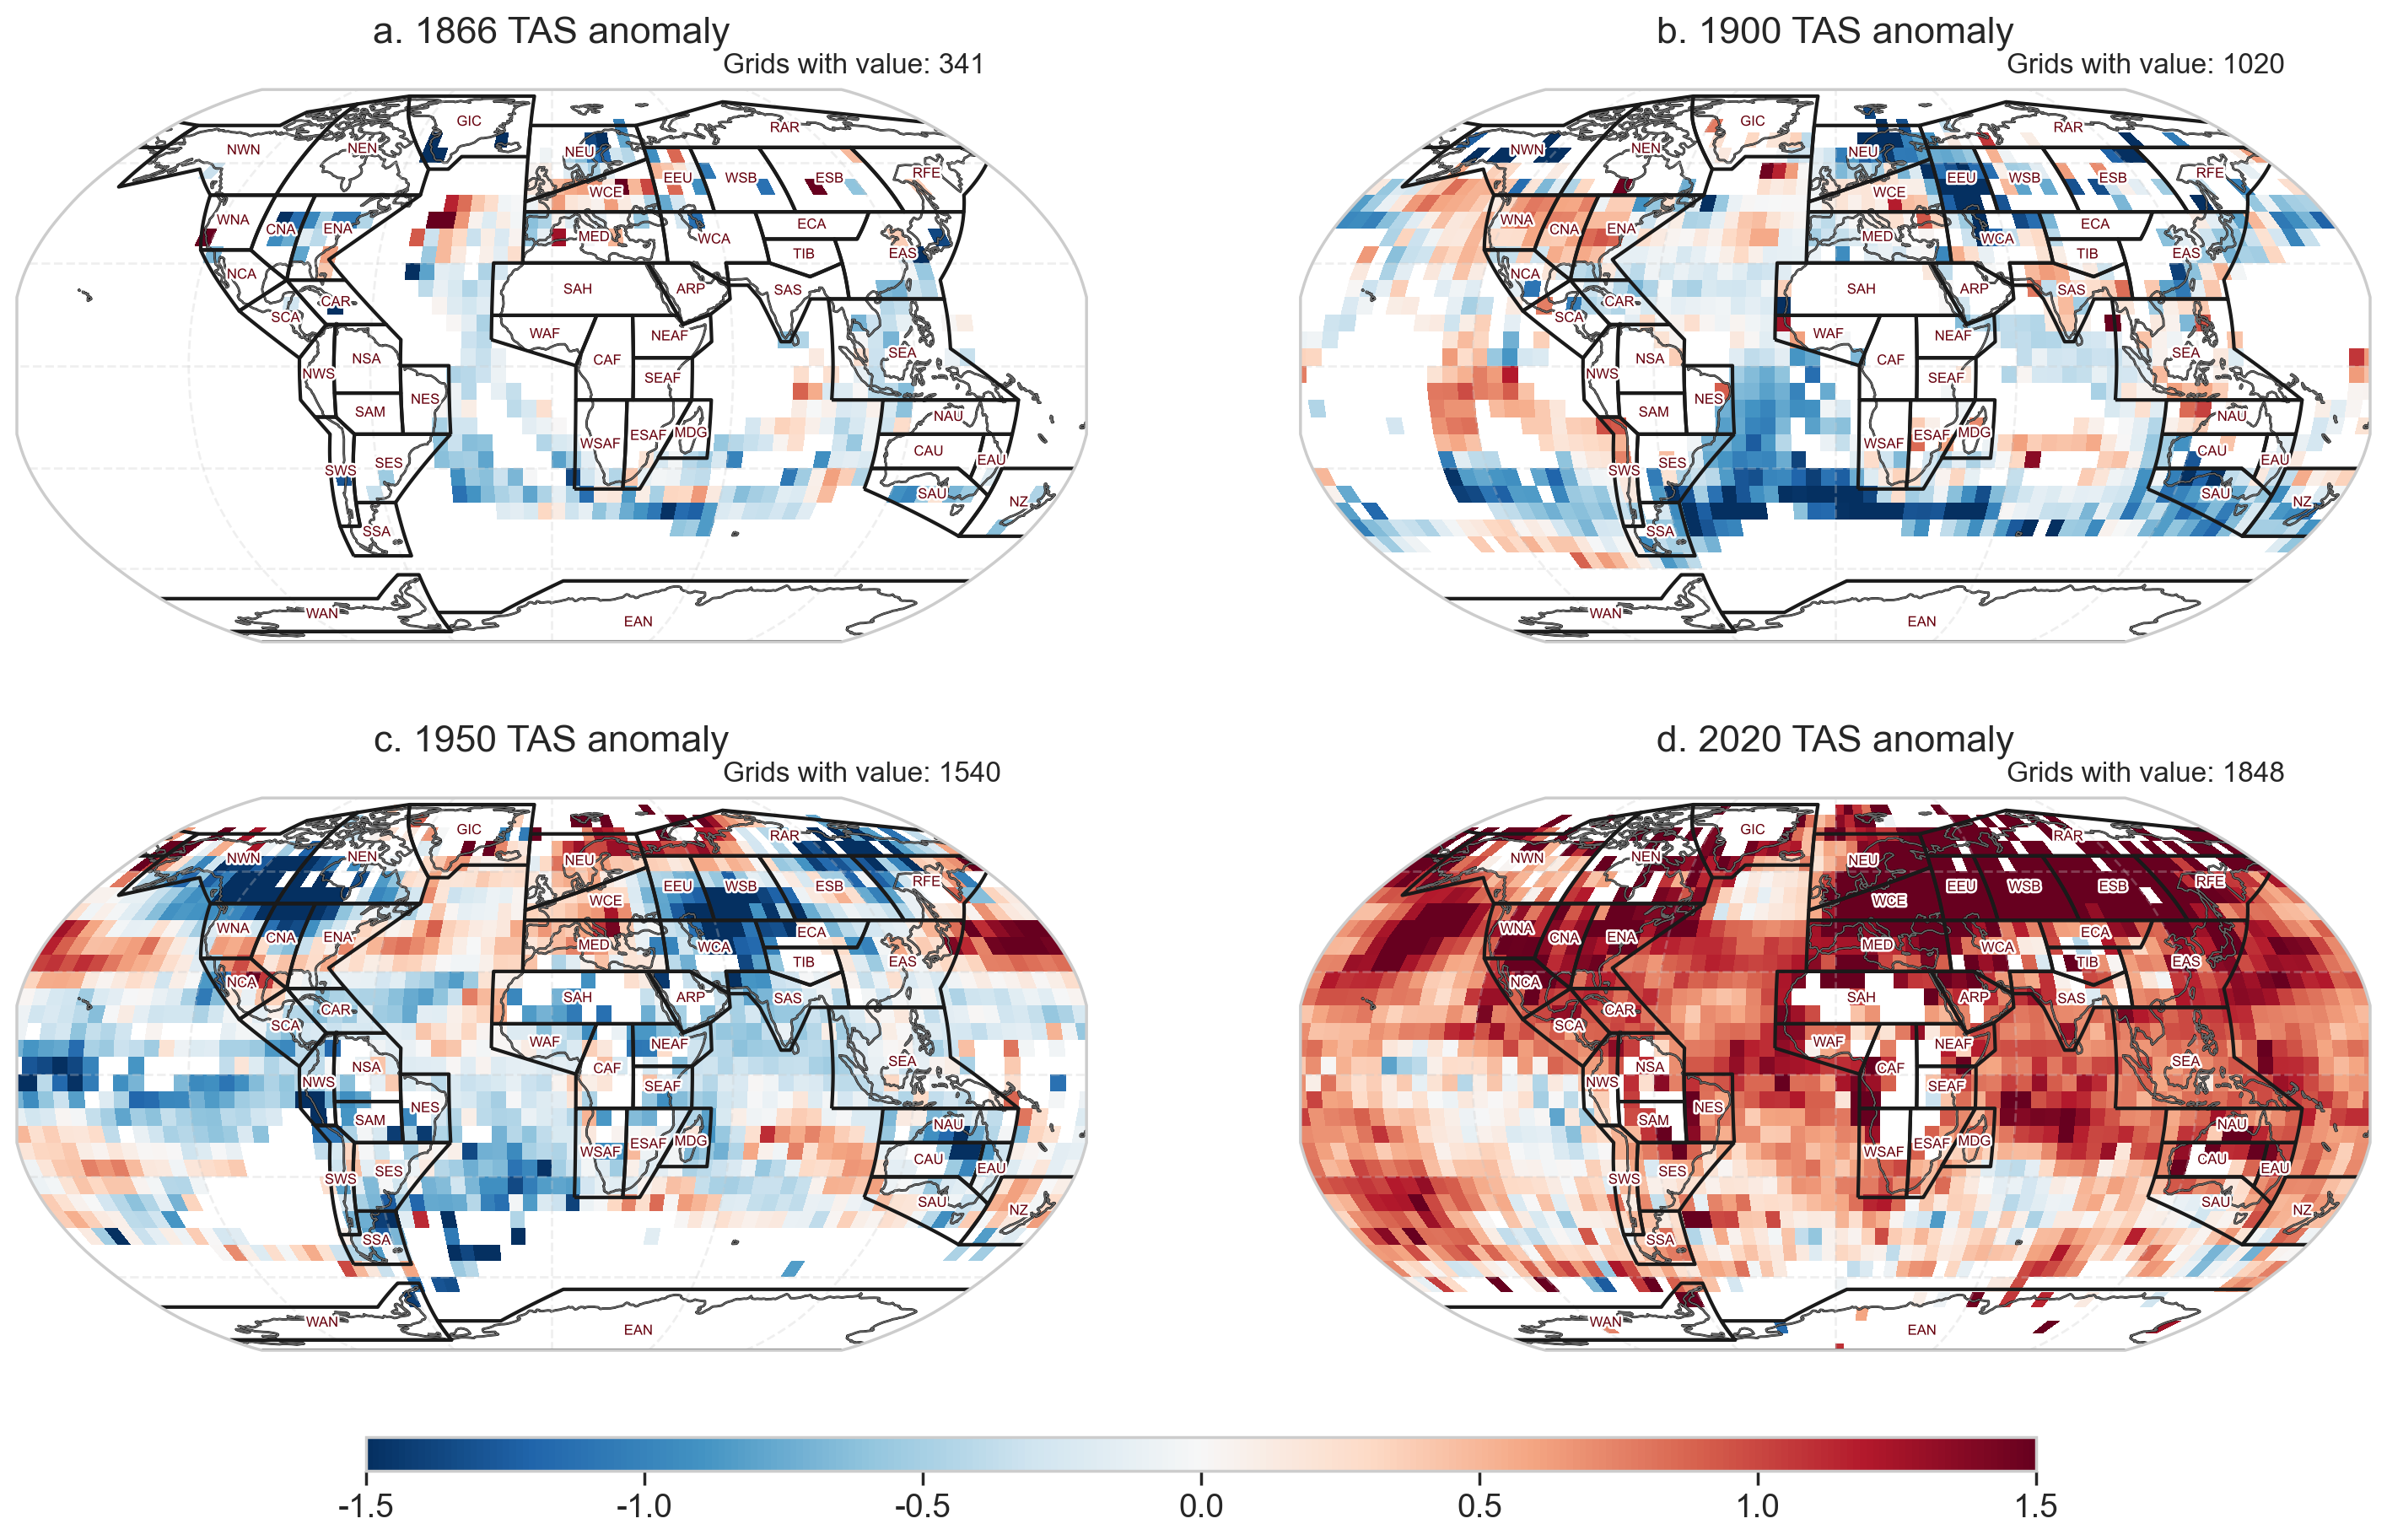

In [6]:
years = [1866, 1900, 1950, 2020]

plot_tas_anomaly_maps(
    tas_had_yr_75per,
    years,
    notnan_counts_grid_had,
    cmap=plt.cm.RdBu_r,
    vmin=-1.5,
    vmax=1.5,
    proj=ccrs.Robinson(),
    figsize=(18, 10),
    dpi=200,
)

In [7]:
result_ar6_polygon = compute_global_ar6_mean(tas_had_yr_75per, threshold=0.3)
global_ar6_mean_mask = result_ar6_polygon["global_ar6_mean_masked"]
grid_fraction_ar6_polygon = result_ar6_polygon["grid_fraction"] * 100

valid_years = global_ar6_mean_mask.year.where(global_ar6_mean_mask.notnull(), drop=True)

In [8]:
# Compare three global series from tas_had_yr_75per:
# 1. all available HadCRUT5 grid cells, 2. AR6 land-region polygons, 3. Natural Earth land-only grid cells.
# The third series is the closest here to a pure global land series.
regionmask.set_options(cache_dir="./input_file/regionmask_cache")


def compute_global_land_mean(tas_data, threshold=0.3):
    """Compute an area-weighted global land-only mean using a Natural Earth land mask."""
    land_regions = regionmask.defined_regions.natural_earth_v5_1_2.land_110
    land_mask = land_regions.mask(tas_data.isel(year=0)).notnull()
    tas_land = tas_data.where(land_mask)

    weights = np.cos(np.deg2rad(tas_data.lat))
    global_land_mean_complete = tas_land.weighted(weights).mean(dim=("lat", "lon"))

    grid_fraction = (
        tas_land.notnull().sum(dim=("lat", "lon"))
        / land_mask.sum(dim=("lat", "lon"))
    )
    global_land_mean_masked = global_land_mean_complete.where(grid_fraction > threshold)

    return {
        "tas_land": tas_land,
        "land_mask": land_mask,
        "global_land_mean_complete": global_land_mean_complete,
        "grid_fraction": grid_fraction,
        "global_land_mean_masked": global_land_mean_masked,
    }


result_land = compute_global_land_mean(tas_had_yr_75per, threshold=0)
global_land_mean_mask = result_land["global_land_mean_masked"].sel(year = valid_years)
global_mean = area_weighted_mean(tas_had_yr_75per).sel(year = valid_years)



,series,period,warming_ref_1850_1900,base_valid_years,period_valid_years
0,Global temperature,2011-2020,1.072,16,10
1,Global temperature,2015-2024,1.218,16,10
2,AR6 global land,2011-2020,1.366,16,10
3,AR6 global land,2015-2024,1.549,16,10
4,Only global land,2011-2020,1.574,16,10
5,Only global land,2015-2024,1.787,16,10


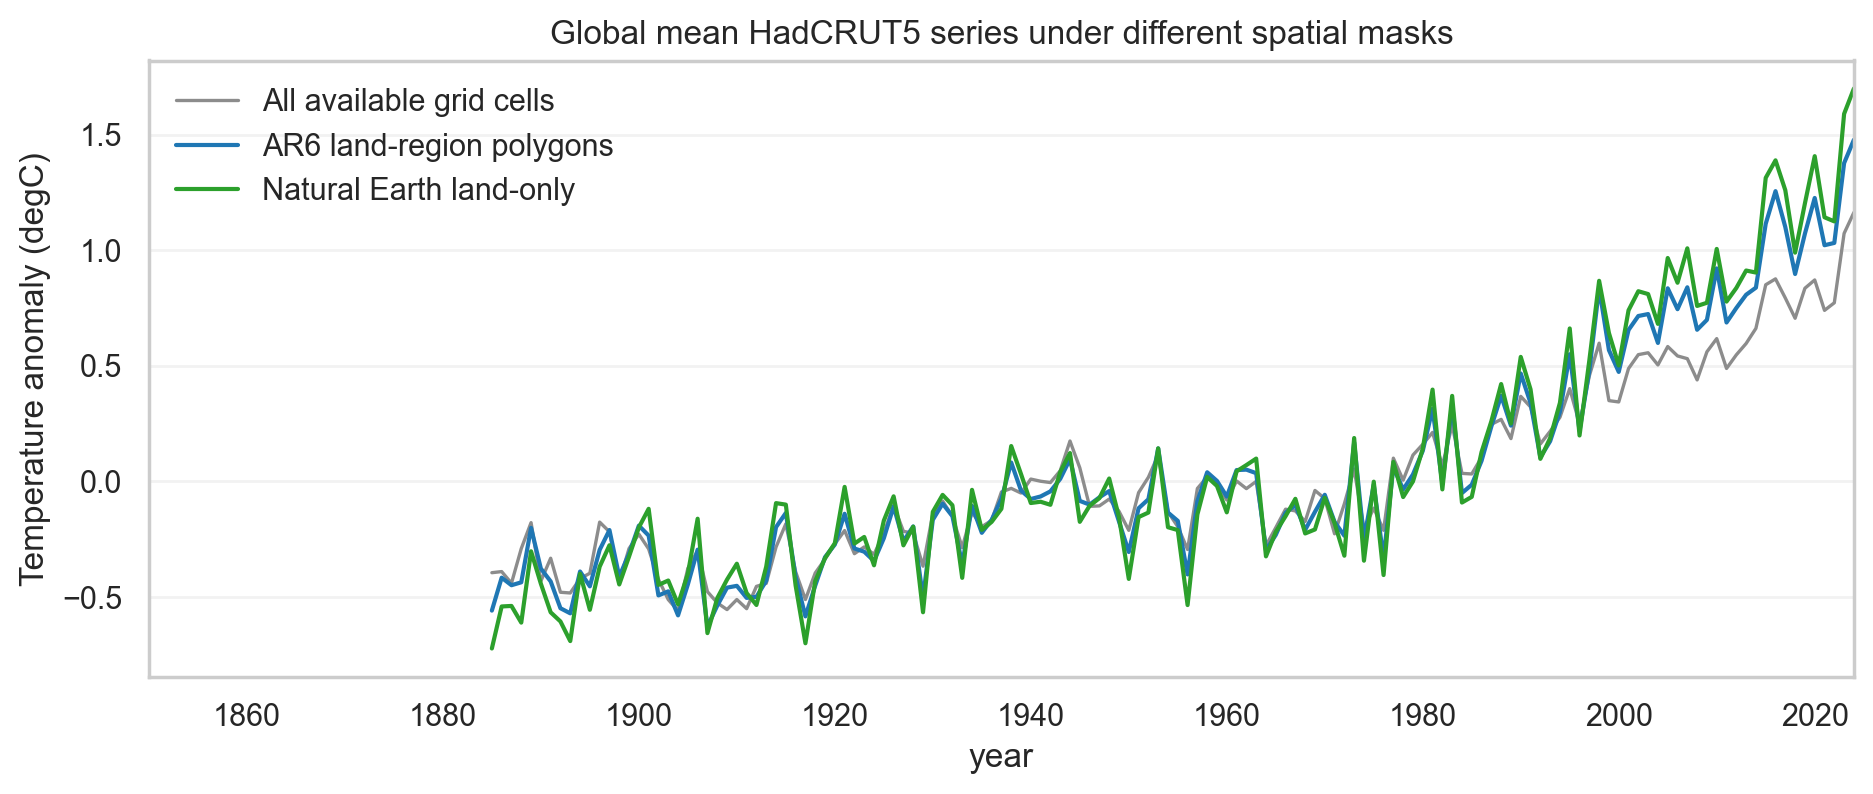

In [9]:
def warming_summary(series, label, base=(1850, 1900), periods=((2011, 2020), (2015, 2024))):
    base_slice = series.sel(year=slice(*base))
    base_mean = base_slice.mean(skipna=True)
    rows = []
    for period in periods:
        period_slice = series.sel(year=slice(*period))
        period_mean = period_slice.mean(skipna=True)
        rows.append(
            {
                "series": label,
                "period": f"{period[0]}-{period[1]}",
                "warming_ref_1850_1900": float(period_mean - base_mean),
                "base_valid_years": int(base_slice.notnull().sum()),
                "period_valid_years": int(period_slice.notnull().sum()),
            }
        )
    return rows


warming_table = pd.DataFrame(
    warming_summary(global_mean, "Global temperature")
    + warming_summary(global_ar6_mean_mask, "AR6 global land")
    + warming_summary(global_land_mean_mask, "Only global land")
)

display(warming_table.round(3))

fig, ax = plt.subplots(figsize=(11, 4), dpi=200)
global_mean.plot(ax=ax, label="All available grid cells", color="0.55", linewidth=1.2)
global_ar6_mean_mask.plot(ax=ax, label="AR6 land-region polygons", color="tab:blue", linewidth=1.5)
global_land_mean_mask.plot(ax=ax, label="Natural Earth land-only", color="tab:green", linewidth=1.5)
ax.set_xlim(1850, 2024)
ax.set_ylabel("Temperature anomaly (degC)")
ax.set_title("Global mean HadCRUT5 series under different spatial masks")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.show()


### To check if early missingness is systematically seasonal 

In [10]:
# Build masks for missing-data diagnostics on the monthly grid.
# This keeps the seasonal information before the annual QC/averaging step.
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import regionmask

ar6_land = regionmask.defined_regions.ar6.land
ar6_land_mask = ar6_land.mask(tas_had_yr_mon_nan.isel(year=0, month=0)).notnull()
valid_ar6_land = tas_had_yr_mon_nan.sel(year = slice(1850, 2023)).where(ar6_land_mask).notnull()

total_ar6_land_grids = ar6_land_mask.sum(dim=("lat", "lon"))
month_valid_fraction = (
    valid_ar6_land.sum(dim=("lat", "lon")) / total_ar6_land_grids
)

season_months = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

# Seasonal availability follows the same idea as the quarterly QC:
# a season is available for a grid-year if at least one month in that season exists.
season_valid_ar6_land = xr.concat(
    [valid_ar6_land.sel(month=months).any("month") for months in season_months.values()],
    dim=pd.Index(season_months.keys(), name="season"),
)
season_valid_fraction = (
    season_valid_ar6_land.sum(dim=("lat", "lon")) / total_ar6_land_grids
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


The first plot answers the direct seasonal question at global AR6-land scale. If early missingness is systematically seasonal, the month heatmap will show persistent horizontal bands and the seasonal lines will separate clearly.

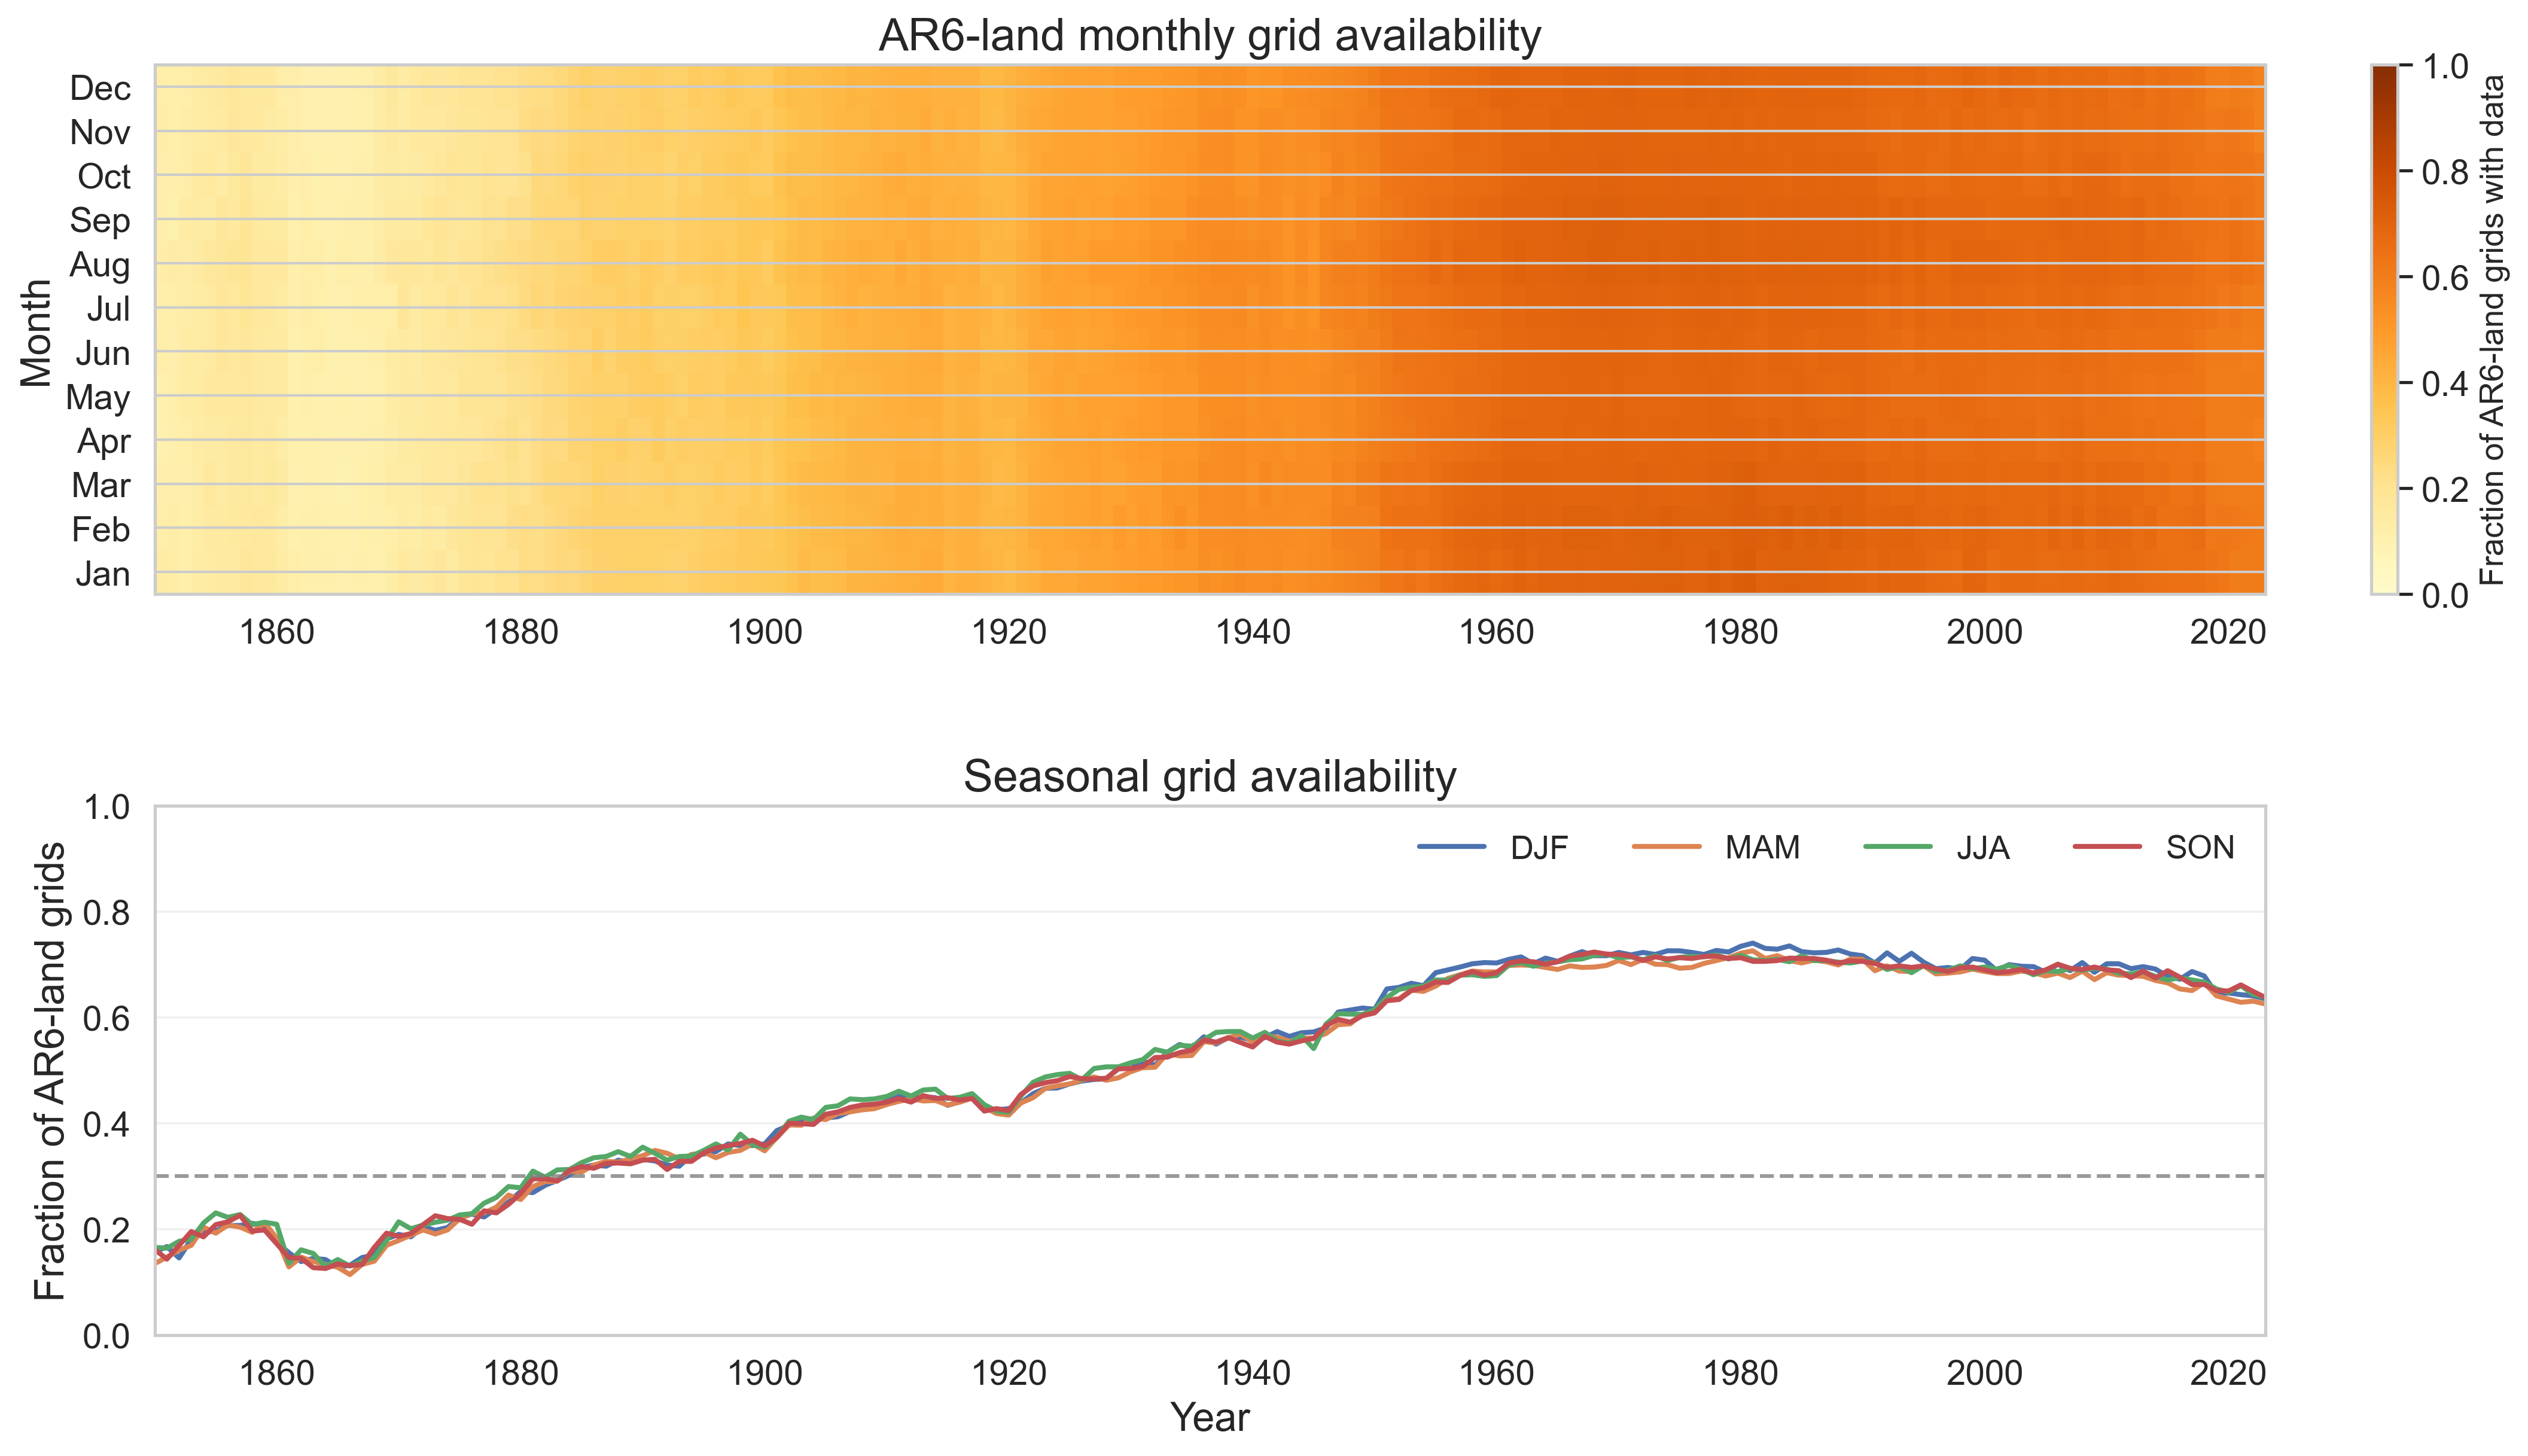

In [13]:
import matplotlib.colors as colors
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Font sizes
title_fs = 18
label_fs = 16
tick_fs = 14
legend_fs = 13
cbar_fs = 13

cmap = sns.color_palette("YlOrBr", as_cmap=True)
colors_array = cmap(np.linspace(0, 1, 256))
truncated_colors = colors_array[20:236]
truncated_cmap = colors.LinearSegmentedColormap.from_list(
    "truncated_YlOrBr", truncated_colors
)

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 8),
    dpi=300,
    constrained_layout=True
)

fig.set_constrained_layout_pads(hspace=0.15)

# =====================
# Monthly availability
# =====================
month_matrix = month_valid_fraction.transpose("month", "year").values

im = axes[0].imshow(
    month_matrix,
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=1,
    extent=[
        int(month_valid_fraction.year.min()),
        int(month_valid_fraction.year.max()),
        0.5,
        12.5,
    ],
    cmap=truncated_cmap,
)

axes[0].set_yticks(np.arange(1, 13))
axes[0].set_yticklabels(month_labels, fontsize=tick_fs)
axes[0].tick_params(axis='x', labelsize=tick_fs)
axes[0].set_ylabel("Month", fontsize=label_fs)
axes[0].set_title("AR6-land monthly grid availability", fontsize=title_fs)

cbar = fig.colorbar(im, ax=axes[0])
cbar.set_label("Fraction of AR6-land grids with data", fontsize=cbar_fs)
cbar.ax.tick_params(labelsize=tick_fs)

# =====================
# Seasonal availability
# =====================
for season in season_valid_fraction.season.values:
    axes[1].plot(
        season_valid_fraction.year,
        season_valid_fraction.sel(season=season),
        label=str(season),
        linewidth=2,
    )

# 30% reference line
axes[1].axhline(
    0.3,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
)

axes[1].set_ylim(0, 1)
axes[1].set_xlim(
    int(season_valid_fraction.year.min()),
    int(season_valid_fraction.year.max())
)

axes[1].set_ylabel("Fraction of AR6-land grids", fontsize=label_fs)
axes[1].set_xlabel("Year", fontsize=label_fs)
axes[1].set_title("Seasonal grid availability", fontsize=title_fs)

axes[1].tick_params(axis='both', labelsize=tick_fs)

axes[1].legend(
    ncol=4,
    frameon=False,
    fontsize=legend_fs,
)

axes[1].grid(axis="y", alpha=0.25)

plt.show()
fig.savefig('../saved_figures/Fig.R2.pdf', dpi=300, bbox_inches='tight')

In [12]:
3362 - 390

# 106+135+149

2972